In [29]:
import pandas as pd

data = pd.read_csv("../Crop_recommendation.csv")
print(data.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
data = pd.read_csv("../Crop_recommendation.csv")

In [32]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [33]:
data.shape

(2200, 8)

In [34]:
data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [35]:
data.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [37]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [38]:
data['label'].value_counts()

rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: label, dtype: int64

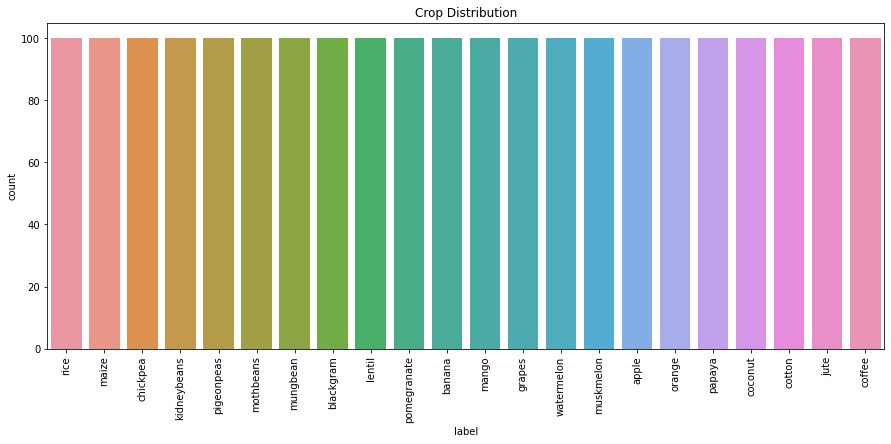

In [39]:
plt.figure(figsize=(15,6))
sns.countplot(x='label', data=data)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

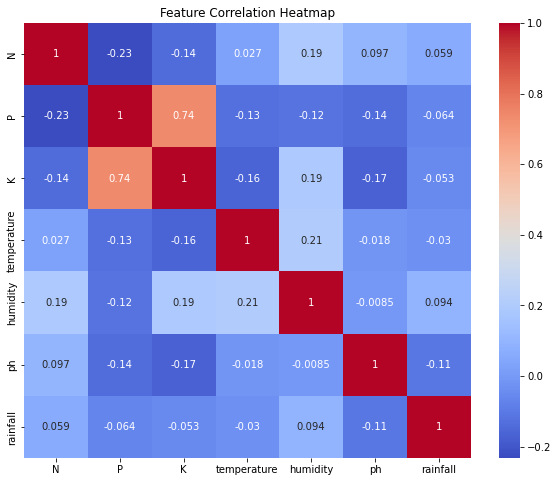

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(data.drop('label', axis=1).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [41]:
X = data.drop('label', axis=1)
y = data['label']

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9931818181818182


In [45]:
sample = [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]]

prediction = model.predict(sample)

print("Recommended Crop:", prediction[0])

Recommended Crop: rice


In [46]:
import pickle
from pathlib import Path

MODEL_FILENAME = "crop_model.pkl"


def get_float(prompt):
    while True:
        value = input(prompt).strip()
        if value == "":
            print("Input cannot be empty. Please enter a numeric value.")
            continue
        try:
            return float(value)
        except ValueError:
            print("Invalid input. Please enter a valid number.")


def load_model(filename=MODEL_FILENAME):
    path = Path(filename)
    if not path.exists():
        possible_paths = [
            Path.cwd() / filename,
            Path.cwd().parent / filename,
            Path.cwd() / "dataset" / "notebook" / filename,
            Path.cwd().parent / "dataset" / "notebook" / filename,
        ]
        for candidate in possible_paths:
            if candidate.exists():
                path = candidate
                break
    if not path.exists():
        raise FileNotFoundError(
            f"Model file not found. Searched: {filename} and fallback locations."
        )
    with path.open("rb") as f:
        return pickle.load(f)


model = load_model()

N = get_float("Enter Nitrogen: ")
P = get_float("Enter Phosphorus: ")
K = get_float("Enter Potassium: ")
temperature = get_float("Enter Temperature: ")
humidity = get_float("Enter Humidity: ")
ph = get_float("Enter pH value: ")
rainfall = get_float("Enter Rainfall: ")

sample = [[N, P, K, temperature, humidity, ph, rainfall]]

prediction = model.predict(sample)

print("Recommended Crop:", prediction[0])

Recommended Crop: rice


In [49]:
import joblib

# Save model using joblib (compatible and recommended for sklearn objects)
joblib.dump(model, "crop_model.pkl")

['crop_model.pkl']

In [50]:
import pickle

pickle.dump(model, open("crop_model.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!
